In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
count =0;
limit=5;
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if count<limit:
            print(os.path.join(dirname, filename))
            count=count+1
        else: 
            break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adityajn105/flickr8k/captions.txt
/kaggle/input/datasets/adityajn105/flickr8k/Images/3226254560_2f8ac147ea.jpg
/kaggle/input/datasets/adityajn105/flickr8k/Images/214543992_ce6c0d9f9b.jpg
/kaggle/input/datasets/adityajn105/flickr8k/Images/2366643786_9c9a830db8.jpg
/kaggle/input/datasets/adityajn105/flickr8k/Images/3368819708_0bfa0808f8.jpg


In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [3]:
base = "/kaggle/input/datasets/adityajn105/flickr8k"
print(os.listdir(base))

['captions.txt', 'Images']


In [4]:
import os

# Corrected dataset path
DATASET_DIR = "/kaggle/input/datasets/adityajn105/flickr8k"
IMAGES_DIR = os.path.join(DATASET_DIR, "Images")
CAPTIONS_FILE = os.path.join(DATASET_DIR, "captions.txt")

# Working directory for OUR outputs (features, checkpoints, vocab, etc.)
WORK_DIR = "/kaggle/working"
FEATURES_DIR = os.path.join(WORK_DIR, "features")
MODELS_DIR = os.path.join(WORK_DIR, "models")

os.makedirs(FEATURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)


print("Images dir exists:", os.path.exists(IMAGES_DIR))
print("Captions file exists:", os.path.exists(CAPTIONS_FILE))
print("Number of images found:", len(os.listdir(IMAGES_DIR)))

Images dir exists: True
Captions file exists: True
Number of images found: 8091


In [5]:
import pandas as pd

df = pd.read_csv(CAPTIONS_FILE)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 10 rows:")
df.head(10)

Shape: (40455, 2)

Columns: ['image', 'caption']

First 10 rows:


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


In [6]:
num_unique_images = df['image'].nunique()
num_total_captions = len(df)

print(f"Unique images: {num_unique_images}")
print(f"Total captions: {num_total_captions}")
print(f"Captions per image: {num_total_captions / num_unique_images:.1f}")

Unique images: 8091
Total captions: 40455
Captions per image: 5.0


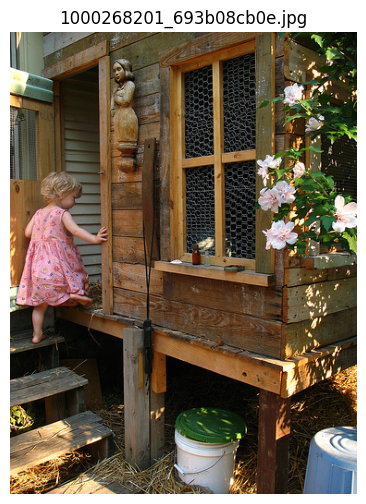

Captions:
  1. A child in a pink dress is climbing up a set of stairs in an entry way .
  2. A girl going into a wooden building .
  3. A little girl climbing into a wooden playhouse .
  4. A little girl climbing the stairs to her playhouse .
  5. A little girl in a pink dress going into a wooden cabin .


In [7]:
import matplotlib.pyplot as plt
from PIL import Image

def show_sample(image_filename, df, images_dir):
    img_path = os.path.join(images_dir, image_filename)
    img = Image.open(img_path)

    captions = df[df['image'] == image_filename]['caption'].tolist()

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(image_filename)
    plt.show()

    print("Captions:")
    for i, cap in enumerate(captions, 1):
        print(f"  {i}. {cap}")

# Test on the first image
sample_image = df['image'].unique()[0]
show_sample(sample_image, df, IMAGES_DIR)

Caption length stats:
count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64


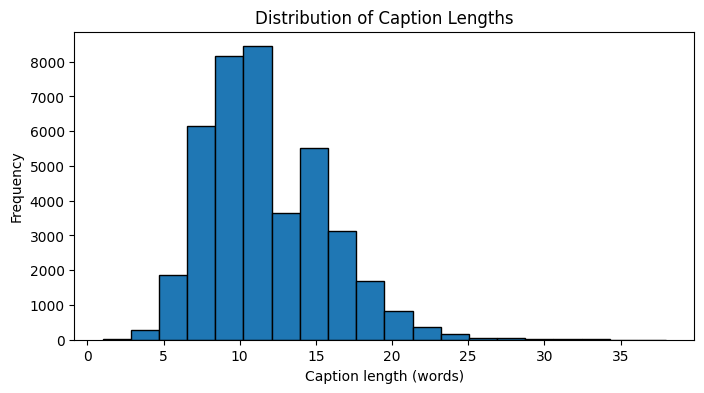

In [8]:
df['caption_length'] = df['caption'].apply(lambda x: len(x.split()))

print("Caption length stats:")
print(df['caption_length'].describe())

plt.figure(figsize=(8, 4))
plt.hist(df['caption_length'], bins=20, edgecolor='black')
plt.xlabel("Caption length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of Caption Lengths")
plt.show()

In [9]:
import re

def clean_caption(caption):
    """Lowercase, remove punctuation/numbers, add start/end tokens."""
    caption = caption.lower()
    caption = re.sub(r'[^a-z\s]', '', caption)   # keep only letters and spaces
    caption = re.sub(r'\s+', ' ', caption).strip()  # collapse multiple spaces
    caption = f"startseq {caption} endseq"
    return caption

# Apply to all captions
df['clean_caption'] = df['caption'].apply(clean_caption)

# Check 
for i in range(5):
    print("Original:", df['caption'].iloc[i])
    print("Cleaned :", df['clean_caption'].iloc[i])
    print()

Original: A child in a pink dress is climbing up a set of stairs in an entry way .
Cleaned : startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq

Original: A girl going into a wooden building .
Cleaned : startseq a girl going into a wooden building endseq

Original: A little girl climbing into a wooden playhouse .
Cleaned : startseq a little girl climbing into a wooden playhouse endseq

Original: A little girl climbing the stairs to her playhouse .
Cleaned : startseq a little girl climbing the stairs to her playhouse endseq

Original: A little girl in a pink dress going into a wooden cabin .
Cleaned : startseq a little girl in a pink dress going into a wooden cabin endseq



In [10]:
from collections import Counter

# Count word frequency across ALL cleaned captions
all_words = []
for caption in df['clean_caption']:
    all_words.extend(caption.split())

word_counts = Counter(all_words)

print("Total words (with repeats):", len(all_words))
print("Unique words (before filtering):", len(word_counts))

# Filter: keep only words appearing at least 5 times (removes typos/rare words)
MIN_WORD_FREQ = 5
vocab_words = [word for word, count in word_counts.items() if count >= MIN_WORD_FREQ]

print("Unique words (after filtering, freq >= 5):", len(vocab_words))

Total words (with repeats): 517248
Unique words (before filtering): 8780
Unique words (after filtering, freq >= 5): 2986


In [11]:

vocab = ['<pad>', '<unk>'] + sorted(vocab_words)

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}

VOCAB_SIZE = len(vocab)
print("Final vocabulary size:", VOCAB_SIZE)

# Quick sanity checks
print("\nIndex of 'startseq':", word2idx.get('startseq', 'NOT FOUND'))
print("Index of 'endseq':", word2idx.get('endseq', 'NOT FOUND'))
print("Index of '<pad>':", word2idx['<pad>'])
print("Index of '<unk>':", word2idx['<unk>'])
print("Word at index 100:", idx2word[100])

Final vocabulary size: 2988

Index of 'startseq': 2480
Index of 'endseq': 832
Index of '<pad>': 0
Index of '<unk>': 1
Word at index 100: attention


In [12]:
import pickle

vocab_data = {
    'word2idx': word2idx,
    'idx2word': idx2word,
    'vocab_size': VOCAB_SIZE
}

vocab_path = os.path.join(WORK_DIR, "vocab.pkl")
with open(vocab_path, 'wb') as f:
    pickle.dump(vocab_data, f)

print("Vocabulary saved to:", vocab_path)
print("File size:", os.path.getsize(vocab_path), "bytes")

Vocabulary saved to: /kaggle/working/vocab.pkl
File size: 59206 bytes


In [13]:
def tokenize_caption(caption, word2idx):
    """Convert a cleaned caption string into a list of word indices."""
    words = caption.split()
    return [word2idx.get(word, word2idx['<unk>']) for word in words]

# Apply to all captions
df['tokenized'] = df['clean_caption'].apply(lambda x: tokenize_caption(x, word2idx))

# Check a few examples
for i in range(3):
    print("Caption:", df['clean_caption'].iloc[i])
    print("Tokens :", df['tokenized'].iloc[i])
    print()

Caption: startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
Tokens : [2480, 2, 492, 1275, 2, 1872, 764, 1308, 526, 2819, 2, 2217, 1692, 2465, 1275, 50, 1, 2900, 832]

Caption: startseq a girl going into a wooden building endseq
Tokens : [2480, 2, 1052, 1073, 1306, 2, 2955, 350, 832]

Caption: startseq a little girl climbing into a wooden playhouse endseq
Tokens : [2480, 2, 1476, 1052, 526, 1306, 2, 2955, 1903, 832]



In [14]:
import torch
import torch.nn as nn
from torchvision import models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(device)
resnet.eval()  # inference mode — no dropout/batchnorm updates

# Freeze all parameters — we're NOT training this, only extracting features
for param in resnet.parameters():
    param.requires_grad = False

print("ResNet50 loaded and ready for feature extraction")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


ResNet50 loaded and ready for feature extraction


In [15]:

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test it on one image
test_img_path = os.path.join(IMAGES_DIR, df['image'].iloc[0])
test_img = Image.open(test_img_path).convert('RGB')
test_tensor = preprocess(test_img)

print("Original image size:", test_img.size)
print("Preprocessed tensor shape:", test_tensor.shape)
print("Tensor min/max values:", test_tensor.min().item(), test_tensor.max().item())

Original image size: (375, 500)
Preprocessed tensor shape: torch.Size([3, 224, 224])
Tensor min/max values: -2.0836544036865234 2.5877127647399902


In [16]:
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Custom Dataset for loading images
class ImageDataset(Dataset):
    def __init__(self, image_filenames, images_dir, transform):
        self.image_filenames = image_filenames
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        filename = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, filename)
        img = Image.open(img_path).convert('RGB')
        img_tensor = self.transform(img)
        return img_tensor, filename

# Get unique image filenames
unique_images = df['image'].unique().tolist()
print("Total unique images to process:", len(unique_images))

# Create dataset and dataloader
image_dataset = ImageDataset(unique_images, IMAGES_DIR, preprocess)
image_loader = DataLoader(image_dataset, batch_size=32, shuffle=False, num_workers=2)

print("DataLoader ready. Batches:", len(image_loader))

Total unique images to process: 8091
DataLoader ready. Batches: 253


In [17]:
import numpy as np

image_features = {}

with torch.no_grad():  # no gradients needed — huge memory/speed saving
    for img_tensors, filenames in tqdm(image_loader, desc="Extracting features"):
        img_tensors = img_tensors.to(device)
        
        # Forward pass through ResNet50 (frozen, feature extraction only)
        features = resnet(img_tensors)  # shape: (batch, 2048, 1, 1)
        features = features.squeeze(-1).squeeze(-1)  # shape: (batch, 2048)
        features = features.cpu().numpy()
        
        # Store each image's feature vector
        for filename, feature in zip(filenames, features):
            image_features[filename] = feature

print("\nDone! Total features extracted:", len(image_features))
print("Feature vector shape (example):", list(image_features.values())[0].shape)

Extracting features: 100%|██████████| 253/253 [00:44<00:00,  5.64it/s]


Done! Total features extracted: 8091
Feature vector shape (example): (2048,)


In [18]:
import pickle

features_path = os.path.join(WORK_DIR, "image_features.pkl")

with open(features_path, 'wb') as f:
    pickle.dump(image_features, f)

print("Features saved to:", features_path)
print("File size (MB):", os.path.getsize(features_path) / (1024 * 1024))

Features saved to: /kaggle/working/image_features.pkl
File size (MB): 63.69647407531738


In [19]:
import numpy as np

np.random.seed(42)  # reproducibility — professional habit

unique_images_list = df['image'].unique().tolist()
np.random.shuffle(unique_images_list)

n = len(unique_images_list)
train_split = int(0.85 * n)
val_split = int(0.95 * n)

train_images = set(unique_images_list[:train_split])
val_images = set(unique_images_list[train_split:val_split])
test_images = set(unique_images_list[val_split:])

print("Train images:", len(train_images))
print("Val images:", len(val_images))
print("Test images:", len(test_images))

# Split the dataframe accordingly
train_df = df[df['image'].isin(train_images)].reset_index(drop=True)
val_df = df[df['image'].isin(val_images)].reset_index(drop=True)
test_df = df[df['image'].isin(test_images)].reset_index(drop=True)

print("\nTrain captions:", len(train_df))
print("Val captions:", len(val_df))
print("Test captions:", len(test_df))

Train images: 6877
Val images: 809
Test images: 405

Train captions: 34385
Val captions: 4045
Test captions: 2025


In [20]:
from torch.nn.utils.rnn import pad_sequence

MAX_LEN = 35  

class CaptionDataset(Dataset):
    def __init__(self, dataframe, image_features, word2idx, max_len=MAX_LEN):
        self.df = dataframe.reset_index(drop=True)
        self.image_features = image_features
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_filename = row['image']
        tokens = row['tokenized']

        # Truncate if too long
        tokens = tokens[:self.max_len]

        # Get image feature vector
        feature = self.image_features[image_filename]
        feature = torch.tensor(feature, dtype=torch.float32)

        # Caption as tensor
        caption_tensor = torch.tensor(tokens, dtype=torch.long)

        return feature, caption_tensor

def collate_fn(batch):
    """Pad captions in a batch to the same length."""
    features, captions = zip(*batch)
    features = torch.stack(features)
    captions_padded = pad_sequence(captions, batch_first=True, padding_value=word2idx['<pad>'])
    return features, captions_padded

# Create datasets
train_dataset = CaptionDataset(train_df, image_features, word2idx)
val_dataset = CaptionDataset(val_df, image_features, word2idx)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

# Test one sample
sample_feature, sample_caption = train_dataset[0]
print("\nSample feature shape:", sample_feature.shape)
print("Sample caption shape:", sample_caption.shape)
print("Sample caption tokens:", sample_caption)

Train dataset size: 34385
Val dataset size: 4045

Sample feature shape: torch.Size([2048])
Sample caption shape: torch.Size([19])
Sample caption tokens: tensor([2480,    2,  492, 1275,    2, 1872,  764, 1308,  526, 2819,    2, 2217,
        1692, 2465, 1275,   50,    1, 2900,  832])


In [21]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn,
    num_workers=2
)

# Test one batch
sample_features, sample_captions = next(iter(train_loader))
print("Batch features shape:", sample_features.shape)
print("Batch captions shape:", sample_captions.shape)

Batch features shape: torch.Size([32, 2048])
Batch captions shape: torch.Size([32, 26])


In [22]:
class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, feature_dim=2048):
        super(CaptionDecoder, self).__init__()
        
        self.feature_proj = nn.Linear(feature_dim, hidden_dim)
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # LSTM decoder
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        
        # Output layer: predicts next word from vocabulary
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        """
        features: (batch, 2048) - image features
        captions: (batch, seq_len) - token indices (includes startseq...endseq)
        """
        batch_size = features.size(0)
        
        # Project image features to initial hidden/cell state
        h0 = self.feature_proj(features).unsqueeze(0)  # (1, batch, hidden_dim)
        c0 = torch.zeros_like(h0)
        
        # Embed the input captions (we feed all tokens except the last one —
        # model predicts each next word from previous words)
        embedded = self.embedding(captions[:, :-1])  # (batch, seq_len-1, embed_dim)
        embedded = self.dropout(embedded)
        
        # LSTM forward pass
        lstm_out, _ = self.lstm(embedded, (h0, c0))  # (batch, seq_len-1, hidden_dim)
        
        # Predict word probabilities at each timestep
        outputs = self.fc(lstm_out)  # (batch, seq_len-1, vocab_size)
        
        return outputs

# Initialize model
model = CaptionDecoder(vocab_size=VOCAB_SIZE).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

CaptionDecoder(
  (feature_proj): Linear(in_features=2048, out_features=512, bias=True)
  (embedding): Embedding(2988, 256, padding_idx=0)
  (lstm): LSTM(256, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=2988, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 4,923,820


In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<pad>'])
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for features, captions in tqdm(dataloader, desc="Training"):
        features = features.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        outputs = model(features, captions)
        targets = captions[:, 1:]
        loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for features, captions in tqdm(dataloader, desc="Validating"):
            features = features.to(device)
            captions = captions.to(device)
            outputs = model(features, captions)
            targets = captions[:, 1:]
            loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(dataloader)

print("Training functions defined.")

Training functions defined.


In [24]:
NUM_EPOCHS = 15
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint_path = os.path.join(MODELS_DIR, "best_model.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, checkpoint_path)
        print(f"Saved new best model (val_loss: {val_loss:.4f})")

print("\nTraining complete!")
print("Best validation loss:", best_val_loss)


Epoch 1/15


Validating: 100%|██████████| 127/127 [00:00<00:00, 215.76it/s]


Train Loss: 3.6381 | Val Loss: 3.1286
Saved new best model (val_loss: 3.1286)

Epoch 2/15


Validating: 100%|██████████| 127/127 [00:00<00:00, 214.41it/s]


Train Loss: 2.9445 | Val Loss: 2.9175
Saved new best model (val_loss: 2.9175)

Epoch 3/15


...

Train Loss: 1.9362 | Val Loss: 2.9369

Epoch 14/15


Validating: 100%|██████████| 127/127 [00:00<00:00, 228.68it/s]


Train Loss: 1.8999 | Val Loss: 2.9497

Epoch 15/15


Validating: 100%|██████████| 127/127 [00:00<00:00, 217.84it/s]

Train Loss: 1.8654 | Val Loss: 2.9740

Training complete!
Best validation loss: 2.805572723779153


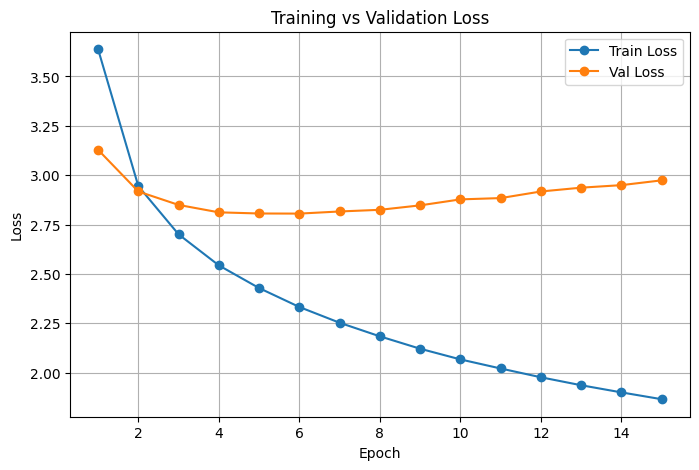

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Loaded best model from epoch 6


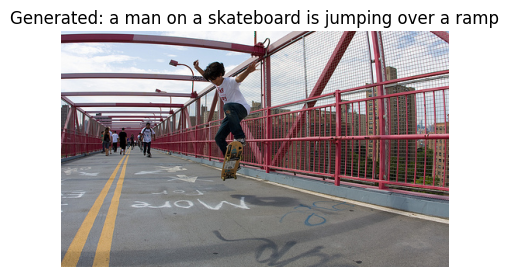

Generated caption: a man on a skateboard is jumping over a ramp
Actual captions (sample): A boy is jumping on skateboard in the middle of a red bridge .
--------------------------------------------------------------------------------


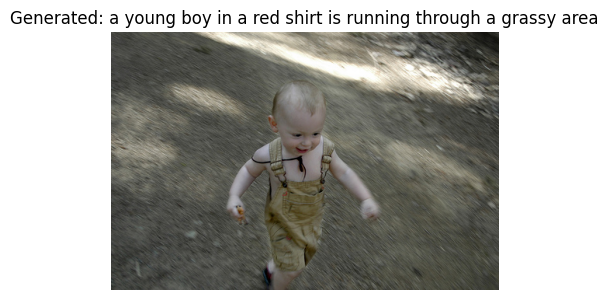

Generated caption: a young boy in a red shirt is running through a grassy area
Actual captions (sample): A child in yellow overalls is walking over packed dirt .
--------------------------------------------------------------------------------


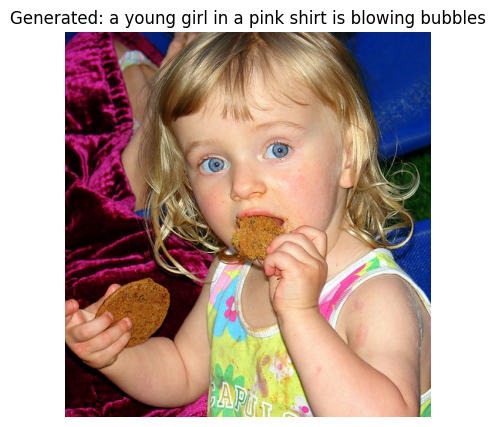

Generated caption: a young girl in a pink shirt is blowing bubbles
Actual captions (sample): A little girl eating two cookies .
--------------------------------------------------------------------------------


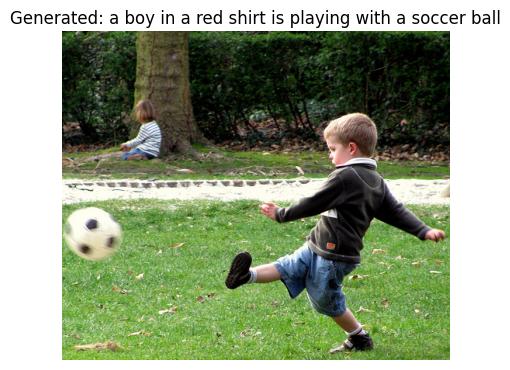

Generated caption: a boy in a red shirt is playing with a soccer ball
Actual captions (sample): A little boy kicks a soccer ball in the park .
--------------------------------------------------------------------------------


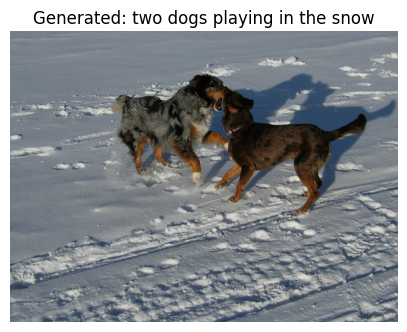

Generated caption: two dogs playing in the snow
Actual captions (sample): A brown and black dog are fighting on snow .
--------------------------------------------------------------------------------


In [26]:
def generate_caption(model, image_feature, word2idx, idx2word, max_len=35, device='cuda'):
    model.eval()
    
    feature = torch.tensor(image_feature, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        h = model.feature_proj(feature).unsqueeze(0)
        c = torch.zeros_like(h)
        
        input_word = torch.tensor([[word2idx['startseq']]], dtype=torch.long).to(device)
        generated_words = []
        
        for _ in range(max_len):
            embedded = model.embedding(input_word)
            lstm_out, (h, c) = model.lstm(embedded, (h, c))
            output = model.fc(lstm_out.squeeze(1))
            predicted_idx = output.argmax(dim=1).item()
            
            predicted_word = idx2word[predicted_idx]
            if predicted_word == 'endseq':
                break
            
            generated_words.append(predicted_word)
            input_word = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)
    
    return ' '.join(generated_words)

# Load best model
checkpoint = torch.load(os.path.join(MODELS_DIR, "best_model.pth"))
model.load_state_dict(checkpoint['model_state_dict'])
print("Loaded best model from epoch", checkpoint['epoch']+1)

# Test on a few test images
import random
test_samples = random.sample(list(test_images), 5)

for img_name in test_samples:
    feature = image_features[img_name]
    generated = generate_caption(model, feature, word2idx, idx2word, device=device)
    
    actual_captions = df[df['image'] == img_name]['caption'].tolist()
    
    img = Image.open(os.path.join(IMAGES_DIR, img_name))
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Generated: " + generated)
    plt.show()
    
    print("Generated caption:", generated)
    print("Actual captions (sample):", actual_captions[0])
    print("-" * 80)

In [27]:
!pip install nltk -q
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

def evaluate_bleu(model, test_df, image_features, word2idx, idx2word, device, num_samples=200):
    model.eval()
    bleu_scores = []
    
    test_images_list = test_df['image'].unique().tolist()
    sample_images = random.sample(test_images_list, min(num_samples, len(test_images_list)))
    
    for img_name in tqdm(sample_images, desc="Evaluating BLEU"):
        feature = image_features[img_name]
        generated = generate_caption(model, feature, word2idx, idx2word, device=device)
        generated_tokens = generated.split()
        
        references = test_df[test_df['image'] == img_name]['caption'].tolist()
        reference_tokens = [ref.lower().split() for ref in references]
        
        score = sentence_bleu(reference_tokens, generated_tokens, smoothing_function=smoothie)
        bleu_scores.append(score)
    
    return sum(bleu_scores) / len(bleu_scores)

avg_bleu = evaluate_bleu(model, test_df, image_features, word2idx, idx2word, device)
print(f"Average BLEU score: {avg_bleu:.4f}")

Evaluating BLEU: 100%|██████████| 200/200 [00:01<00:00, 179.10it/s]

Average BLEU score: 0.1652


In [28]:
!pip install gradio -q
import gradio as gr

def caption_image(uploaded_image):
    """Takes a PIL image, returns generated caption."""
    model.eval()
    
    # Preprocess the uploaded image same way as training data
    img = uploaded_image.convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    
    # Extract CNN feature
    with torch.no_grad():
        feature = resnet(img_tensor)
        feature = feature.squeeze(-1).squeeze(-1).squeeze(0).cpu().numpy()
    
    # Generate caption using our existing function
    caption = generate_caption(model, feature, word2idx, idx2word, device=device)
    
    return caption

print("Caption function ready.")

Caption function ready.


In [29]:
import gradio as gr
gr.close_all()

In [30]:
demo = gr.Interface(
    fn=caption_image,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=gr.Textbox(label="Generated Caption"),
    title="AI Image Captioning",
    description="Upload any image and this CNN+LSTM model will generate a descriptive caption for it."
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://eeac50e7e0bb3036b4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
